Exploratory Data Analysis


Import Libraries

#

In [41]:
import pandas as pd 
import matplotlib.pyplot as plt
import streamlit as sns

Loading Dataset

In [42]:
df=pd.read_csv(r"C:\Users\hp\Desktop\Supermarket Sales Analysis\data\supermart.csv",encoding="latin1")

Data Understanding

In [43]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [45]:
df.isna().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [46]:

df.duplicated().sum()

np.int64(0)

In [47]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning

### Deleting Unwanted Columns

In [48]:
columns=["Row ID","Postal Code","Ship Mode","Segment","Order ID","Customer Name","Country","City","State","Product ID"]

In [49]:
df=df.drop(columns,axis=1)

In [50]:
df.head()

,Order Date,Ship Date,Customer ID,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,CG-12520,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,11/8/2016,11/11/2016,CG-12520,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,6/12/2016,6/16/2016,DV-13045,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,10/11/2015,10/18/2015,SO-20335,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,10/11/2015,10/18/2015,SO-20335,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Changing Dtatype of Colums 

In [51]:
df.dtypes

Order Date          str
Ship Date           str
Customer ID         str
Region              str
Category            str
Sub-Category        str
Product Name        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [52]:
df["Order Date"]=pd.to_datetime(df["Order Date"],errors="coerce")

In [53]:
df["Ship Date"]=pd.to_datetime(df["Ship Date"],errors="coerce")

In [54]:
df.dtypes

Order Date      datetime64[us]
Ship Date       datetime64[us]
Customer ID                str
Region                     str
Category                   str
Sub-Category               str
Product Name               str
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object

### Feature Engineering

In [55]:
df["Order Date"].head()

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[us]

In [56]:
df["Order Month"]=df["Order Date"].dt.month
df["Order Year"]=df["Order Date"].dt.year

In [57]:
df["Ship Month"]=df["Ship Date"].dt.month
df["Ship Year"]=df["Ship Date"].dt.year

In [58]:
df.head()

,Order Date,Ship Date,Customer ID,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Ship Month,Ship Year
0,2016-11-08,2016-11-11,CG-12520,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,11,2016
1,2016-11-08,2016-11-11,CG-12520,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,11,2016
2,2016-06-12,2016-06-16,DV-13045,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6,2016
3,2015-10-11,2015-10-18,SO-20335,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,10,2015
4,2015-10-11,2015-10-18,SO-20335,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,10,2015


## Exploratory Data Analysis

### Basic Overview

In [59]:
df["Sales"].sum()
          

np.float64(2297200.8603)

In [60]:
df["Profit"].sum()


np.float64(286397.0217)

In [61]:
df["Quantity"].sum()

np.int64(37873)

### Total Sales by Region

In [78]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

### Total Sales and Profit by Category

In [63]:
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [64]:
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

### Top Products by Sales

In [65]:
df.groupby(["Product Name","Sub-Category"])["Sales"].sum().sort_values(ascending=False).head(5)

Product Name                                                                 Sub-Category
Canon imageCLASS 2200 Advanced Copier                                        Copiers         61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind  Binders         27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                        Machines        22638.480
HON 5400 Series Task Chairs for Big and Tall                                 Chairs          21870.576
GBC DocuBind TL300 Electric Binding System                                   Binders         19823.479
Name: Sales, dtype: float64

### Top Products by Profit

In [66]:
df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(5)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64

### Top Productes by Quantity

In [67]:
df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(5)

Product Name
Staples                       215
Staple envelope               170
Easy-staple paper             150
Staples in misc. colors        86
KI Adjustable-Height Table     74
Name: Quantity, dtype: int64

In [76]:
df.groupby("Sub-Category")[["Discount","Sales"]].sum()

,Discount,Sales
Sub-Category,,
Accessories,60.80,167380.3180
Appliances,77.60,107532.1610
Art,59.60,27118.7920
Binders,567.00,203412.7330
Bookcases,48.14,114879.9963
Chairs,105.00,328449.1030
Copiers,11.00,149528.0300
Envelopes,20.40,16476.4020
Fasteners,17.80,3024.2800


In [75]:
df.groupby("Order Year")["Sales"].sum().sort_values(ascending=False)

Order Year
2017    733215.2552
2016    609205.5980
2014    484247.4981
2015    470532.5090
Name: Sales, dtype: float64

### Discount vs Sales

<Axes: xlabel='Discount'>

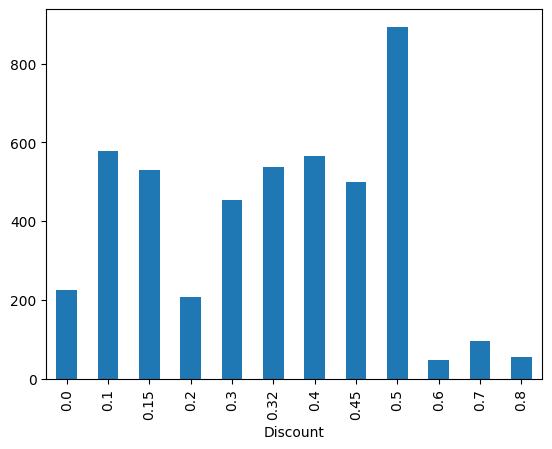

In [73]:
df.groupby("Discount")["Sales"].mean().plot(kind="bar")